# 第083课：表示能力的可执行证据
所有参数固定。本Notebook不训练网络，不报告泛化准确率。

In [1]:
from experiment import affine, collapse, fixed_xor, alternative_xor, parameter_count, interpolate_square, run
print("核心模块已导入；无深度学习框架依赖")
from IPython.display import display, Image

核心模块已导入；无深度学习框架依赖


合并 [[31, 46]] [92]
[1, 0] [123] [123]
[0, 1] [138] [138]


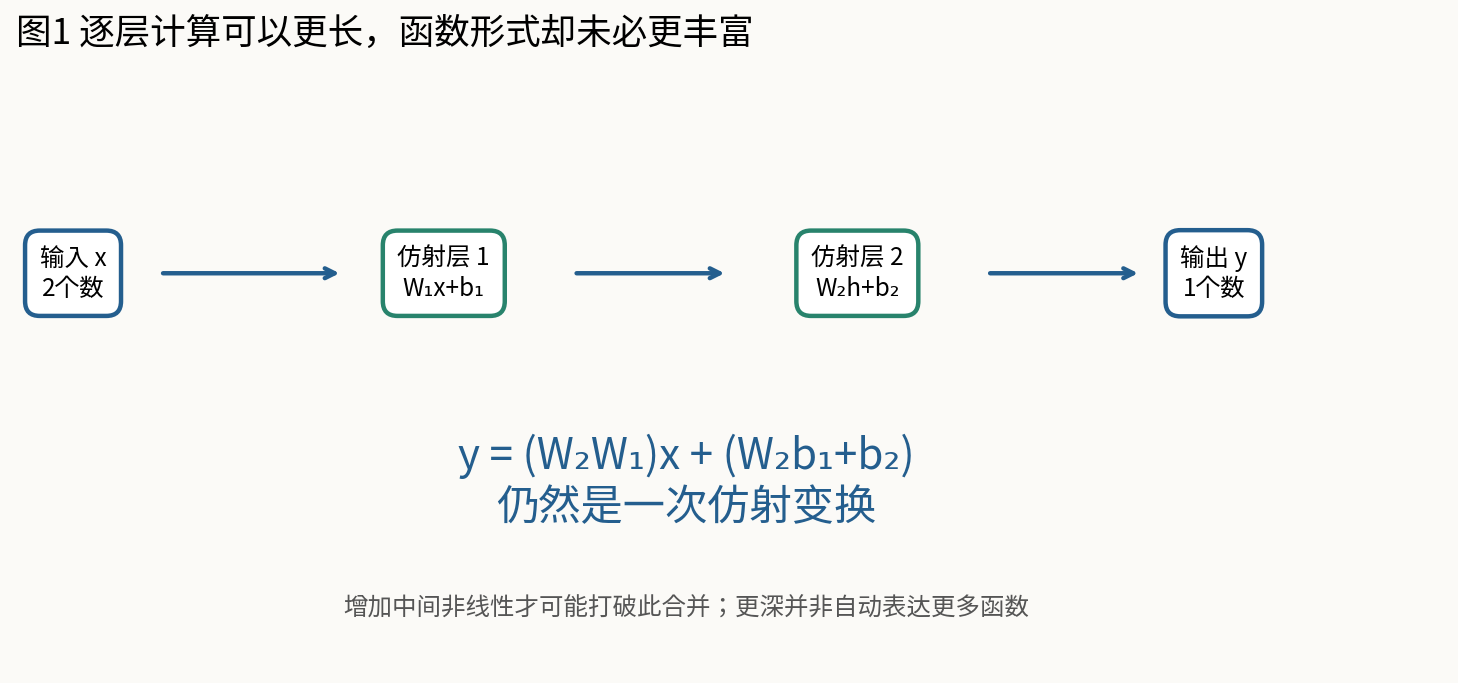

In [2]:
W1,b1=[[1,2],[3,4]],[5,6]
W2,b2=[[7,8]],[9]
W,b=collapse(W1,b1,W2,b2)
print("合并",W,b)
for x in [[1,0],[0,1]]:
    print(x,affine(affine(x,W1,b1),W2,b2),affine(x,W,b))
display(Image(filename="figures/01_affine_collapse.png"))

输入 [0, 0] 隐藏 [0.0, 0.0] 分数 0.0 预测 0
输入 [0, 1] 隐藏 [1.0, 0.0] 分数 1.0 预测 1
输入 [1, 0] 隐藏 [1.0, 0.0] 分数 1.0 预测 1
输入 [1, 1] 隐藏 [2.0, 1.0] 分数 0.0 预测 0


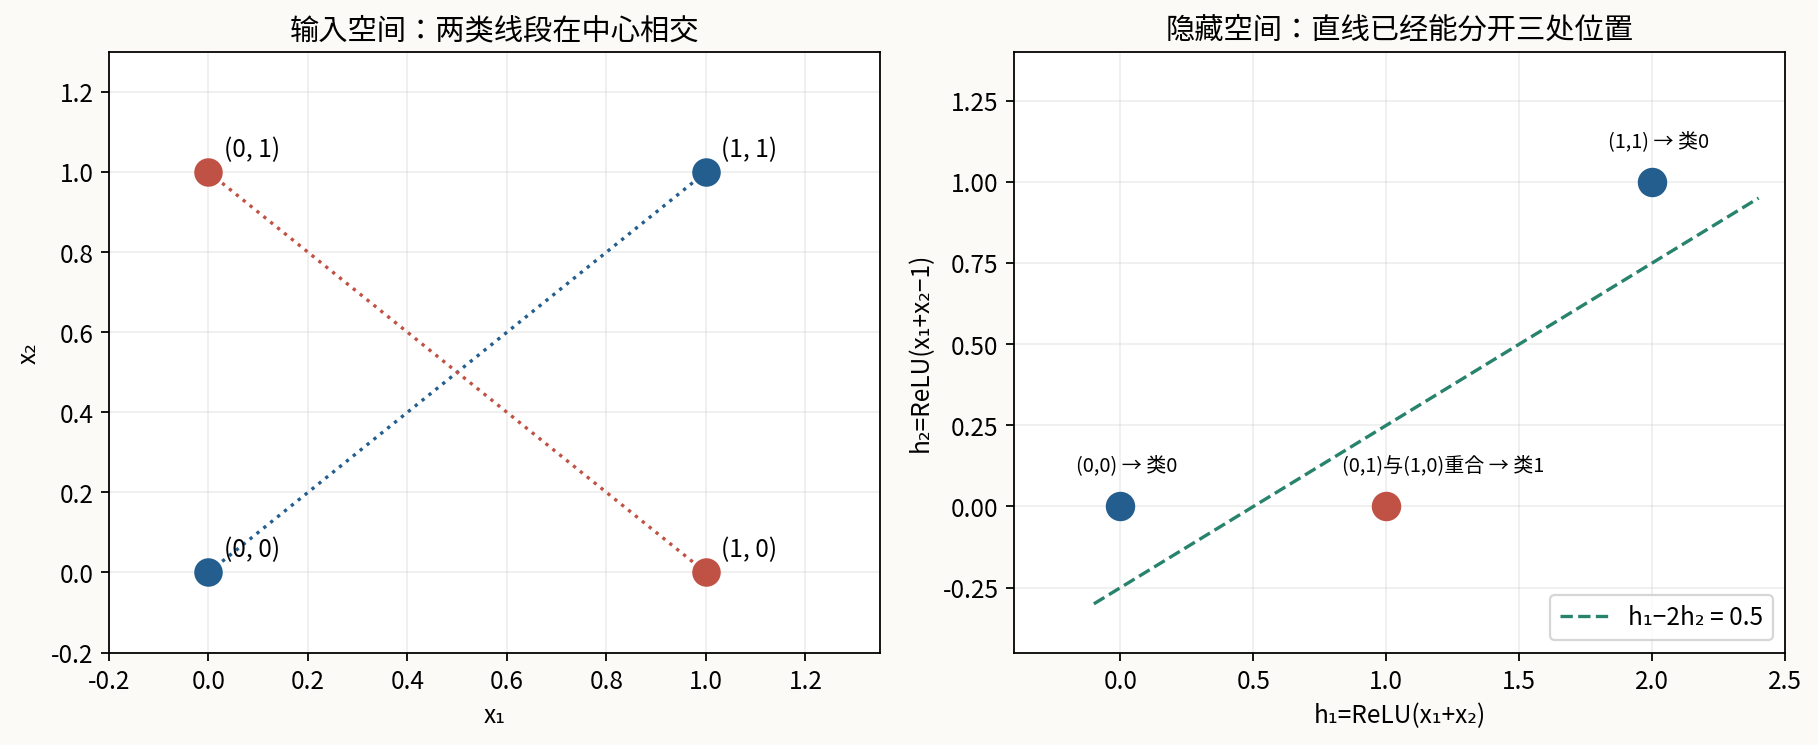

In [3]:
for x in [[0,0],[0,1],[1,0],[1,1]]:
    h,s=fixed_xor(x)
    print("输入",x,"隐藏",h,"分数",s,"预测",int(s>=.5))
display(Image(filename="figures/02_xor_representation.png"))

In [4]:
for x in [[0,0],[0,1],[1,0],[1,1]]:
    print("去掉激活",x,fixed_xor(x,False))
print("参数位置",parameter_count([2,2,1]),parameter_count([2,4,3,1]))

去掉激活 [0, 0] ([0.0, -1.0], 2.0)
去掉激活 [0, 1] ([1.0, 0.0], 1.0)
去掉激活 [1, 0] ([1.0, 0.0], 1.0)
去掉激活 [1, 1] ([2.0, 1.0], 0.0)
参数位置 9 31


[0.5, 0.5] 三角帽 1.0 绝对差 0.0
[0.25, 0.25] 三角帽 0.5 绝对差 0.0
[2, 2] 三角帽 -2.0 绝对差 0.0
四点相同不决定连续区域答案；原始分数不等于概率


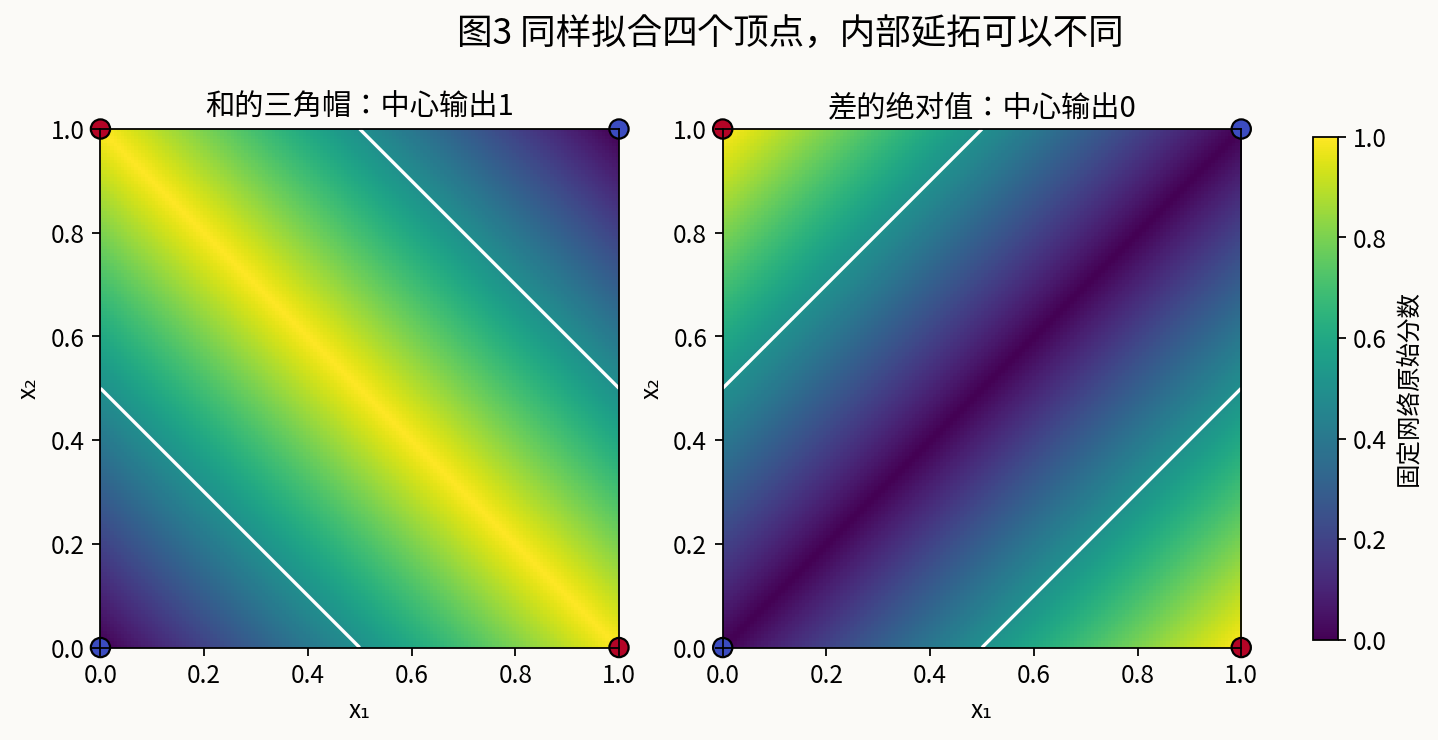

In [5]:
for x in [[.5,.5],[.25,.25],[2,2]]:
    print(x,"三角帽",fixed_xor(x)[1],"绝对差",alternative_xor(x))
print("四点相同不决定连续区域答案；原始分数不等于概率")
display(Image(filename="figures/03_extension_ambiguity.png"))

分段数 2 网格误差 0.0625 区间精确最大 0.0625
分段数 4 网格误差 0.015625 区间精确最大 0.015625
分段数 8 网格误差 0.00390625 区间精确最大 0.00390625
分段数 16 网格误差 0.0009765625 区间精确最大 0.0009765625


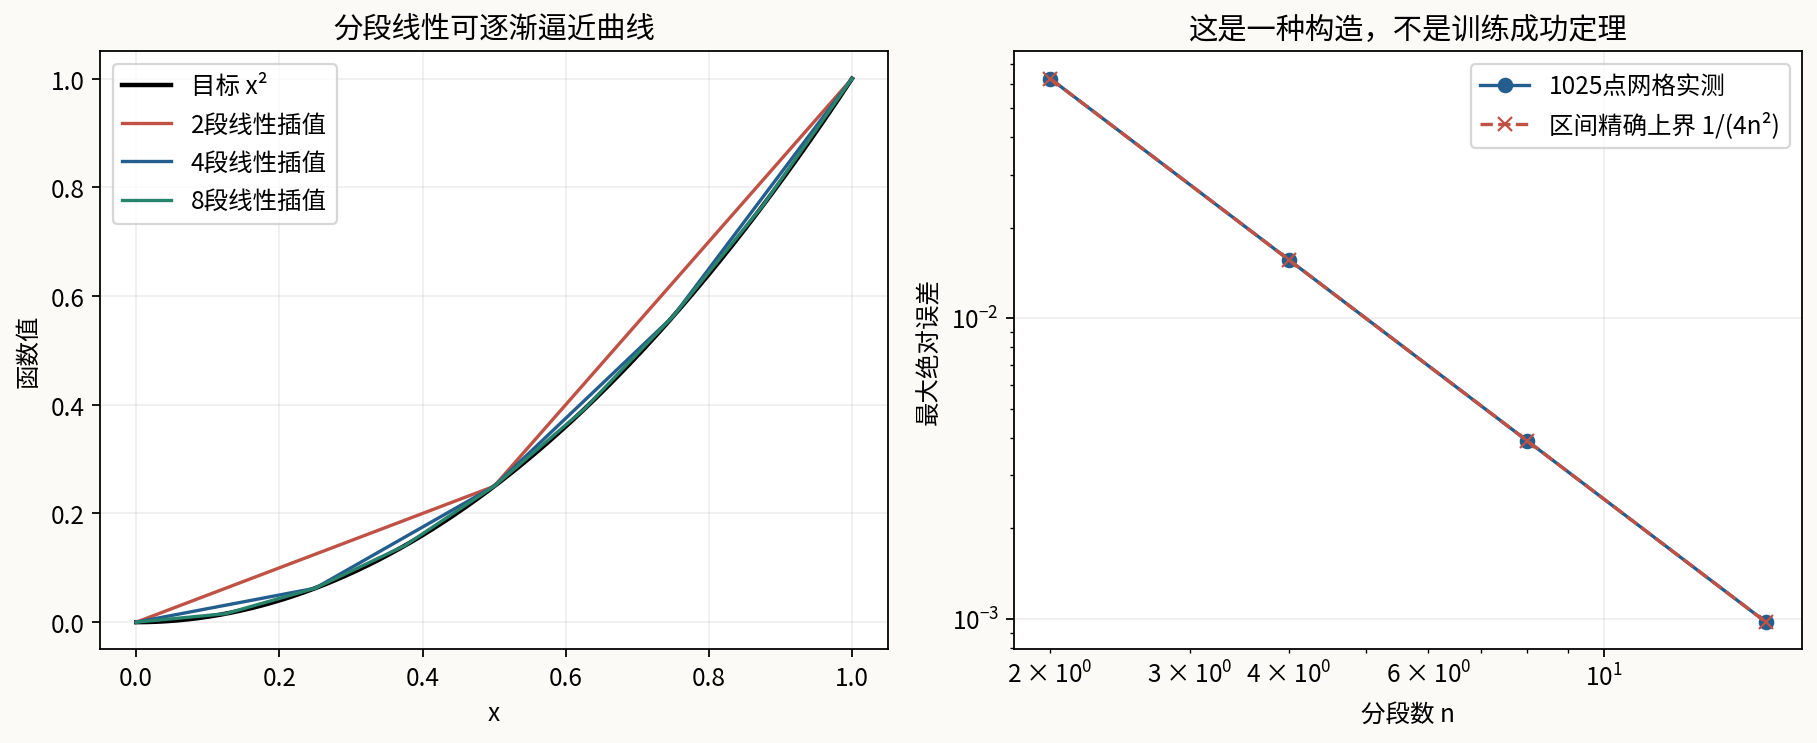

In [6]:
for n in [2,4,8,16]:
    e=max(abs(interpolate_square(i/1024,n)-(i/1024)**2) for i in range(1025))
    print("分段数",n,"网格误差",e,"区间精确最大",1/(4*n*n))
display(Image(filename="figures/04_piecewise_approximation.png"))

In [7]:
result=run()
print("固定XOR",result["fixed_accuracy"])
print("仿射复合最大差",result["affine_collapse_max_abs_error"])
print("有限搜索",result["finite_linear_search"])
print("数据哈希",result["data_sha256"])

固定XOR 1.0
仿射复合最大差 2.220446049250313e-16
有限搜索 {'triples': 729, 'best_accuracy': 0.75, 'witness': [-4, -4, 4], 'warning': 'Finite search is a check, not the impossibility proof.'}
数据哈希 {'square-grid.csv': '7edf1d017851a041a8c2ecb1a6b342562bede430d08c50cfc3ab62d77f1c0554', 'xor.csv': '7d8c8ab2148427ed9d412f746f5b5dedec2e0d2c71159cfb4b4eae41e6832a8c'}


## 独立实现验收
运行真正的unittest测试，不依赖优化模式可能移除的assert。

In [8]:
import unittest
suite=unittest.defaultTestLoader.discover(".", pattern="test_experiment.py")
checks=unittest.TextTestRunner(verbosity=1).run(suite)
if not checks.wasSuccessful():
    raise RuntimeError("unit tests failed")

................
----------------------------------------------------------------------
Ran 16 tests in 0.015s

OK
